In [1]:
import pandas as pd
df = pd.read_parquet("../classify_data.parquet").reset_index()

In [3]:
class_map = {
    '0': 0,
    '1-3': 1,
    '4-7': 2,
    '8-14': 3,
    '15-30': 4,
    '31-60': 5
}
df['resolution_class_int'] = df['resolution_class'].map(class_map)

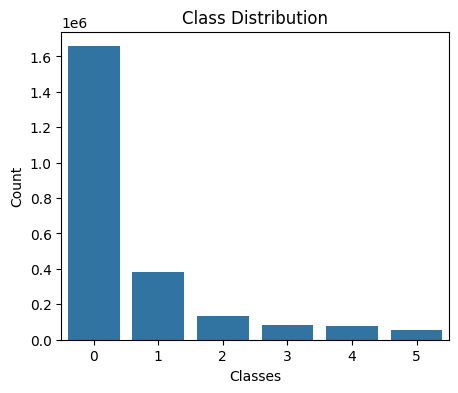

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.countplot(x=df['resolution_class_int'])
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.show()


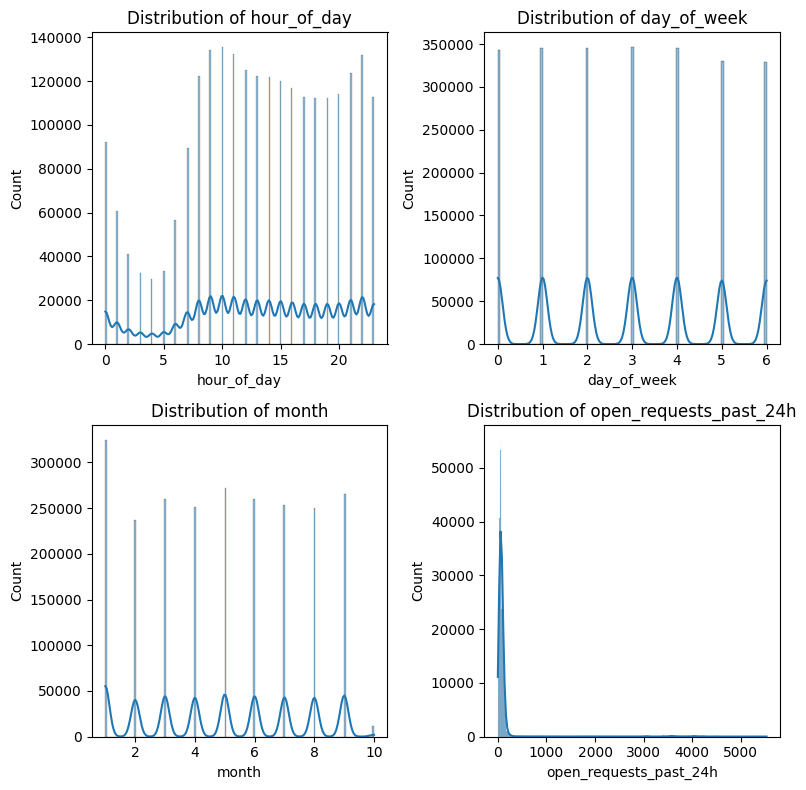

In [11]:
num_cols = ['hour_of_day', 'day_of_week', 'month', 'open_requests_past_24h']

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], ax=axes[i], kde=True)
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()


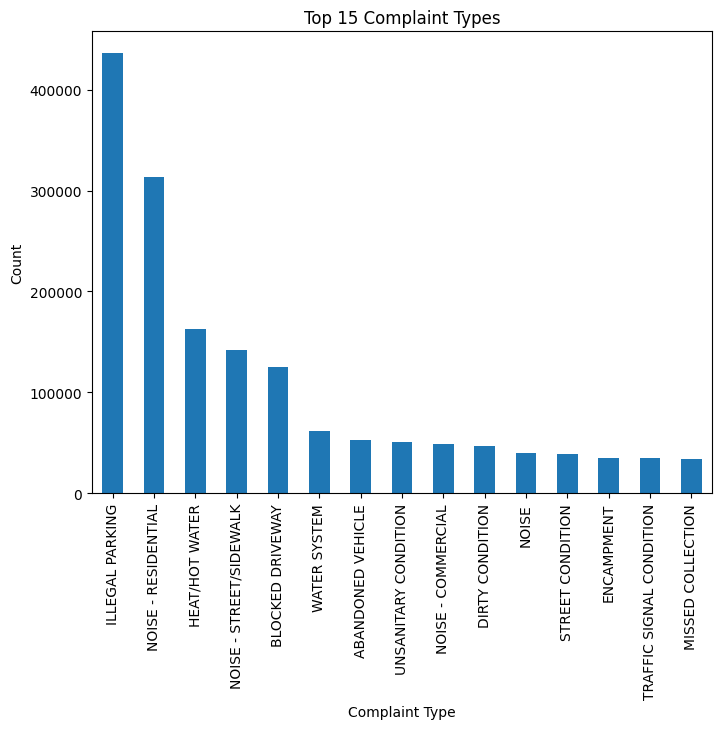

In [14]:
plt.figure(figsize=(8,6))
df['Complaint Type'].value_counts().head(15).plot(kind='bar')
plt.title("Top 15 Complaint Types")
plt.ylabel("Count")
plt.show()


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

feature_columns = ['Agency','Complaint Type','Descriptor','Location Type', 'Incident Zip', 'City', 'Borough',
                    'Open Data Channel Type', 'Latitude', 'Longitude',
                    'hour_of_day', 'day_of_week', 'month',
                    'is_weekend', 'open_requests_past_24h']

X = df[feature_columns]
y = df['resolution_class_int']

#Segregate columsn for preprocessing
categorical_cols = ['Agency','Complaint Type','Descriptor','Location Type', 'Incident Zip', 'City', 'Borough',
                    'Open Data Channel Type',
                    'is_weekend']
numeric_cols = ['Latitude','Longitude','hour_of_day','day_of_week', 'month','open_requests_past_24h']

# Preprocessing -> Normalization + encoding categories
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols)
    ],
    remainder='passthrough'  # numeric features untouched
)

rf = RandomForestClassifier(
    n_estimators=20,
    max_depth=None,
    min_samples_split=10,
    class_weight='balanced',
    n_jobs=8, # Number of threads
    random_state=42,
    verbose=3
)

# 4. Full pipeline: preprocessing + model
model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('clf', rf)
])

# 5. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [17]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='f1_macro')

print(scores)

# 6. Fit model
model.fit(X_train, y_train)

# 7. Predict
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.


building tree 8 of 20
building tree 1 of 20
building tree 2 of 20
building tree 7 of 20
building tree 6 of 20
building tree 3 of 20
building tree 5 of 20
building tree 4 of 20
building tree 9 of 20
building tree 10 of 20
building tree 11 of 20
building tree 12 of 20
building tree 13 of 20
building tree 14 of 20
building tree 15 of 20
building tree 16 of 20
building tree 17 of 20
building tree 18 of 20
building tree 19 of 20
building tree 20 of 20


[Parallel(n_jobs=8)]: Done  12 out of  20 | elapsed:    5.8s remaining:    3.9s
[Parallel(n_jobs=8)]: Done  20 out of  20 | elapsed:    8.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  12 out of  20 | elapsed:    0.4s remaining:    0.3s
[Parallel(n_jobs=8)]: Done  20 out of  20 | elapsed:    0.6s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.


building tree 1 of 20
building tree 7 of 20
building tree 3 of 20
building tree 6 of 20
building tree 8 of 20
building tree 5 of 20
building tree 2 of 20
building tree 4 of 20
building tree 9 of 20
building tree 10 of 20
building tree 11 of 20
building tree 12 of 20
building tree 13 of 20
building tree 14 of 20
building tree 15 of 20
building tree 16 of 20
building tree 17 of 20
building tree 18 of 20
building tree 19 of 20
building tree 20 of 20


[Parallel(n_jobs=8)]: Done  12 out of  20 | elapsed:    6.1s remaining:    4.0s
[Parallel(n_jobs=8)]: Done  20 out of  20 | elapsed:    8.3s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  12 out of  20 | elapsed:    0.4s remaining:    0.3s
[Parallel(n_jobs=8)]: Done  20 out of  20 | elapsed:    0.6s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.


...

[Parallel(n_jobs=8)]: Done  12 out of  20 | elapsed:    6.1s remaining:    4.0s
[Parallel(n_jobs=8)]: Done  20 out of  20 | elapsed:    8.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  12 out of  20 | elapsed:    0.4s remaining:    0.3s
[Parallel(n_jobs=8)]: Done  20 out of  20 | elapsed:    0.6s finished


[0.53640382 0.53546484 0.53572123]


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.


building tree 3 of 20
building tree 6 of 20
building tree 8 of 20
building tree 2 of 20
building tree 7 of 20
building tree 5 of 20
building tree 1 of 20
building tree 4 of 20
building tree 9 of 20
building tree 10 of 20
building tree 11 of 20
building tree 12 of 20
building tree 13 of 20
building tree 14 of 20
building tree 15 of 20
building tree 16 of 20
building tree 17 of 20
building tree 18 of 20
building tree 19 of 20
building tree 20 of 20


[Parallel(n_jobs=8)]: Done  12 out of  20 | elapsed:   10.0s remaining:    6.6s
[Parallel(n_jobs=8)]: Done  20 out of  20 | elapsed:   13.5s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  12 out of  20 | elapsed:    0.4s remaining:    0.3s
[Parallel(n_jobs=8)]: Done  20 out of  20 | elapsed:    0.5s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  12 out of  20 | elapsed:    0.4s remaining:    0.2s
[Parallel(n_jobs=8)]: Done  20 out of  20 | elapsed:    0.5s finished


In [18]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# print(scores)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Test Accuracy: 0.803295073105113

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.90      0.93    331345
           1       0.62      0.68      0.65     76042
           2       0.42      0.46      0.44     27143
           3       0.37      0.44      0.41     17086
           4       0.36      0.49      0.41     15160
           5       0.40      0.60      0.48     10482

    accuracy                           0.80    477258
   macro avg       0.52      0.60      0.55    477258
weighted avg       0.83      0.80      0.81    477258


Confusion Matrix:
 [[297748  23358   4162   1852   2266   1959]
 [  6785  51669   7659   4057   3691   2181]
 [  1165   5570  12582   3493   2787   1546]
 [   591   1644   2890   7583   2921   1457]
 [   399    842   1788   2413   7459   2259]
 [   236    338    778    927   1865   6338]]


In [19]:
import numpy as np
np.save("../results/random_forest_predictions_20.npy", y_pred)
# np.save("../results/random_forest_prob_150.npy", y_proba)

In [8]:
import numpy as np
y_pred = np.load("../results/random_forest_predictions_150.npy")

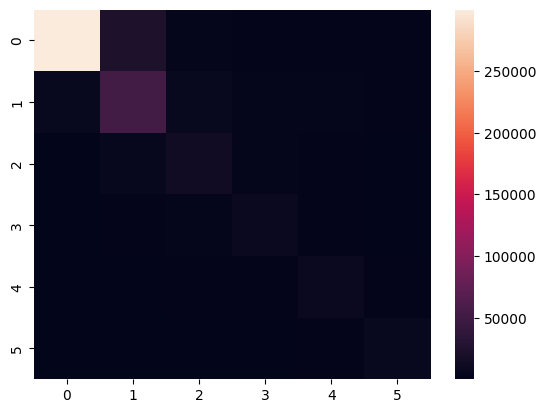

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt 

sns.heatmap(confusion_matrix(y_test, y_pred), annot=False)
plt.savefig("../results/cm_random_forest.png")